In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
import colorsys

# color-friendly plan
# RGB: EF8975; HSV: .028, .510, .937; V: .390~.990 (salmon)
# RGB: 6EBEAF; HSV: .469, .421, .745; V: .350~.850 (teal)
# RGB: 5983F6; HSV: .622, .683, .965; V: .480~.980 (blue)

# Sliver: C0C0C0; SlaterGray: 708090
Sliver = (.75, .75, .75)
Slater = (0.4375, 0.5, 0.5625)

def colorR (v: float = .7):
    return colorsys.hsv_to_rgb(.028, .510, .39+.6*v)
RED = '#d62728'

def colorG (v: float = .7):
    return colorsys.hsv_to_rgb(.469, .421, .35+.5*v)

def colorB (v: float = .7):
    return colorsys.hsv_to_rgb(.622, .683, .48+.5*v)

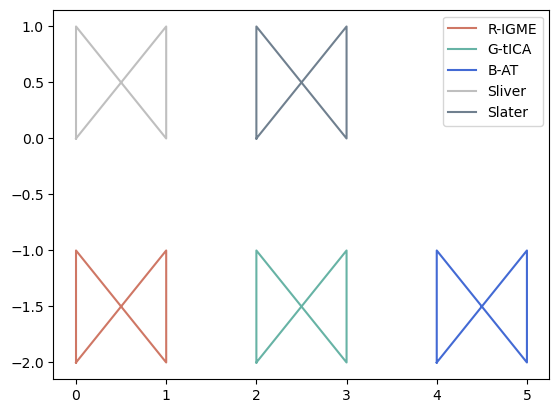

In [3]:
color_test_x, color_test_y = np.array((0, 1, 1, 0, 0)), np.array((0, 1, 0, 1, 0))
plt.plot(color_test_x, color_test_y-2, c=colorR(.7), label='R-IGME')
plt.plot(color_test_x+2, color_test_y-2, c=colorG(.7), label='G-tICA')
plt.plot(color_test_x+4, color_test_y-2, c=colorB(.7), label='B-AT')
plt.plot(color_test_x, color_test_y, c=Sliver, label='Sliver')
plt.plot(color_test_x+2, color_test_y, c=Slater, label='Slater')

plt.legend()
plt.show()

In [4]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


# Figure 1: 1b-1d

In [5]:
F1b = [np.load('Panel_1b1_tICexpansion.npz'), np.load('Panel_1b2_tICexpansion.npz')]
F1b

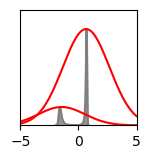

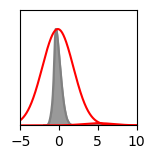

In [6]:
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

x_tIC, counts = F1b[0]['x_tIC'], F1b[0]['counts']
fig = plt.figure(figsize=(1.5,1.5))
'''
ax = fig.add_subplot(111)
for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(width=2)'''
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = -1.43747934, 0.66571087
x_min, x_max = -5, 5
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=26110), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=137041), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-5, 0, 5], fontsize=10)
plt.yticks([])
#plt.title('tIC1 basis')
plt.savefig('Panel_1b1_tICexpansion.svg', bbox_inches="tight", dpi=1000)
plt.show()

x_tIC, counts = F1b[1]['x_tIC'], F1b[1]['counts']
plt.figure(figsize=(1.5,1.5))
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = -0.14983666, 5.10290513
x_min, x_max = -5, 10
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=83084), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=1890), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-5, 0, 5, 10], fontsize=10)
plt.yticks([])
#plt.title('tIC2 basis')
plt.savefig('Panel_1b2_tICexpansion.svg', bbox_inches="tight", dpi=1000)
plt.show()

## 1c 

In [7]:
F1c = np.load('Panel_1c_BootS.npz')
F1c

In [8]:
def plot_error_bar(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (18, 18)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))
    fig, axes = plt.subplots(int(np.ceil(length/size)), size, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for idx in range(length):
        ax = axes[idx//size, idx%size]
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.plot(t, y_pred, linestyle="dashdot", label='Predicted K', color="orange")
        ax.errorbar(t, y_true, yerr=y_err, fmt='o', capsize=3, color="black", label='True w/ 1sigma')
        ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.xticks([])
    plt.show()

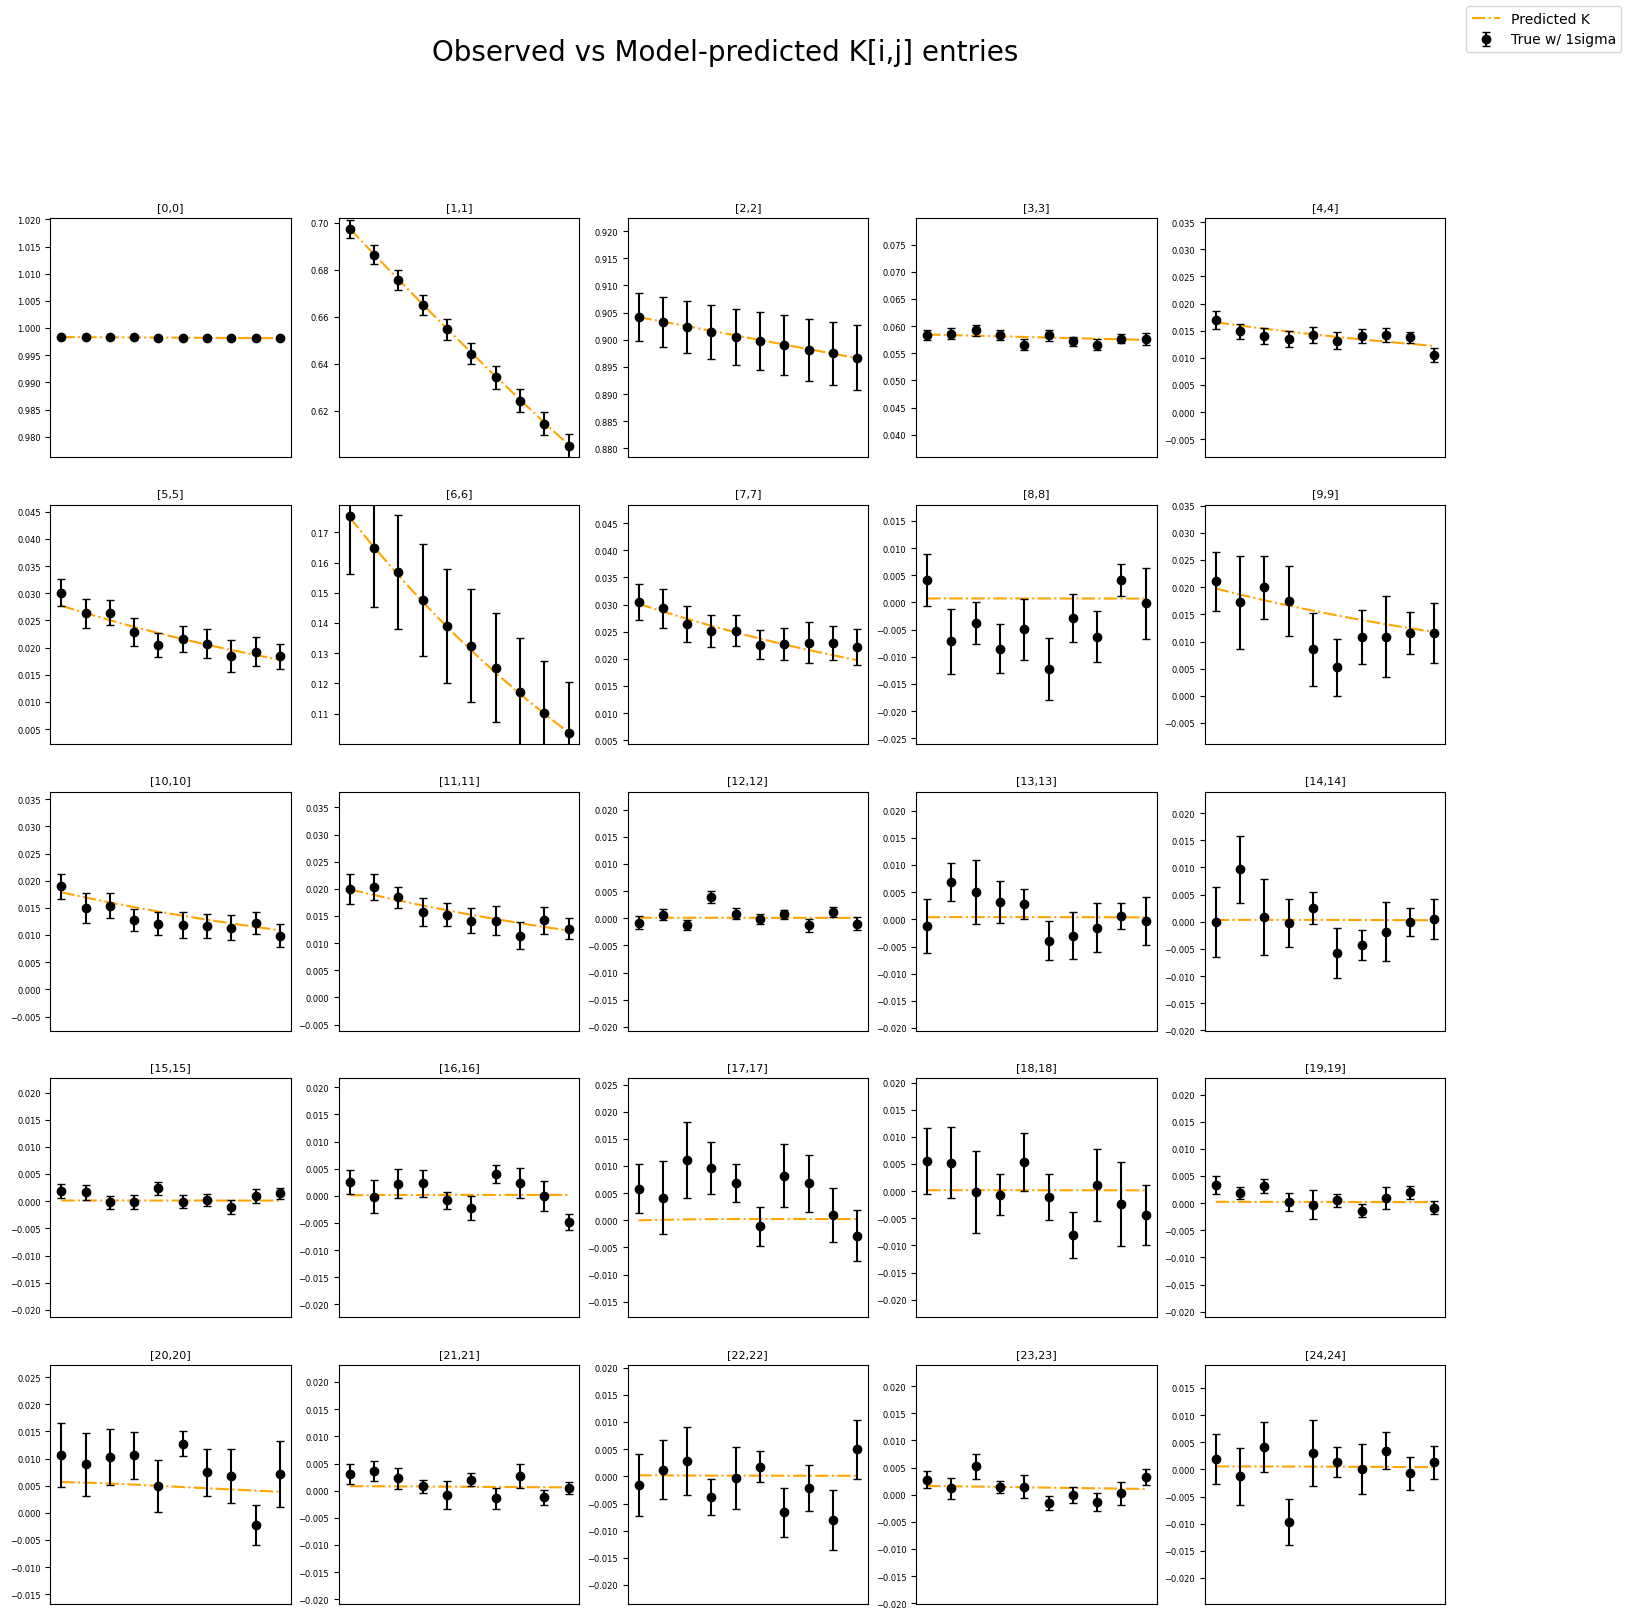

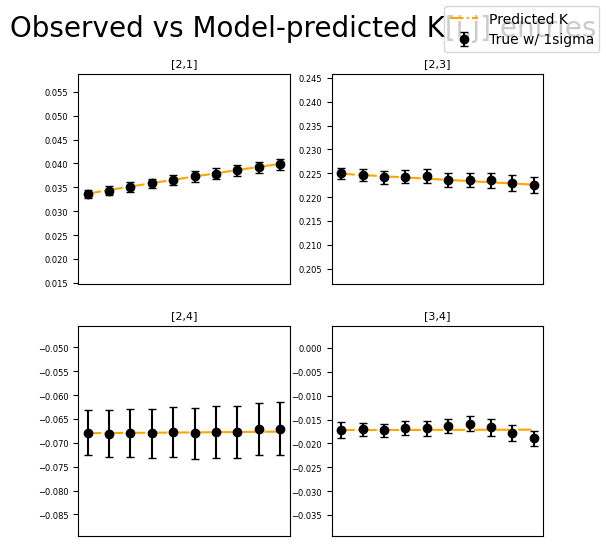

In [9]:
plot_error_bar(F1c['Kpred'], F1c['Ktrue'], F1c['Kerr'], [[i,i] for i in range(25)], y_lim_range = .04)
plot_error_bar(F1c['Kpred'], F1c['Ktrue'], F1c['Kerr'], [[2,1], [2,3], [2,4], [3,4]], y_lim_range = .04, fig_size = (6, 6))

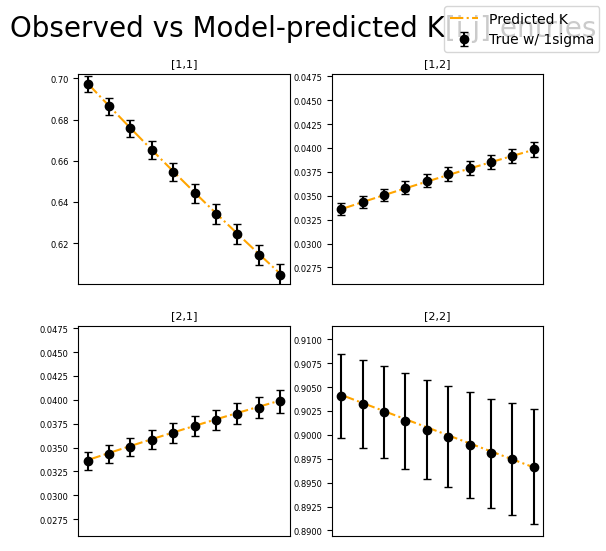

In [10]:
plot_error_bar(F1c['Kpred'], F1c['Ktrue'], F1c['Kerr'], [[1,1], [1,2], [2,1], [2,2]], y_lim_range = .02, fig_size = (6, 6))

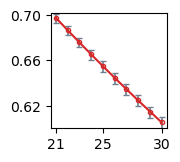

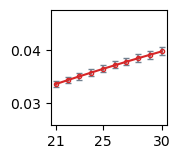

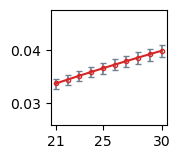

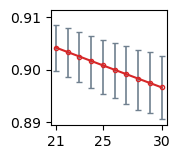

In [11]:
def error_bar_separate(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (1, 1)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))

    for idx in range(length):
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        fig, ax = plt.subplots(figsize=fig_size)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.errorbar(t, y_true, yerr=y_err, fmt='none', linewidth=1.5, elinewidth=1.2, capsize=2, color=Slater, label='True w/ 1sigma')
        ax.plot(t, y_pred, '.-', markerfacecolor='none', label='IGME', color=RED)
        #ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)
        plt.xticks([0, 4, 9], [1+20, 5+20, 10+20], fontsize=10)
        if idx == 0:
            yticks = [.62, .66, .70]
        elif idx == 1 or idx == 2:
            yticks = [.03, .04]
        elif idx == 3:
            yticks = [.89, .90, .91]
        plt.yticks(yticks, fontsize=10)
        plt.savefig(f'Panel_1cBootS_{r[idx]}{c[idx]}.svg', bbox_inches="tight", dpi=1000, transparent=True)
        plt.show()


error_bar_separate(F1c['Kpred'], F1c['Ktrue'], F1c['Kerr'], [[1,1], [1,2], [2,1], [2,2]], y_lim_range = .02, fig_size = (1.5, 1.5))

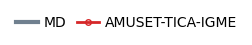

In [18]:
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=Slater, lw=3, label='MD'),
    Line2D([0], [0], color=RED, marker='.', lw=2, markersize=8,
           markerfacecolor='none', label='AMUSET-TICA-IGME'),
]

fig_leg = plt.figure(figsize=(2.5, 0.3))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')

leg = ax_leg.legend(
    handles=legend_elements,
    loc='center',
    ncol=5,
    frameon=False,
    fontsize=10,
    handlelength=1.6,
    columnspacing=0.8,
    handletextpad=0.4
)

fig_leg.savefig("Panel_1cBootS_legend.svg", bbox_inches='tight', transparent=True)
plt.show()

## 1d

In [5]:
F1d = np.load('Panel_1d_ITS.npz')
F1d

NpzFile 'Panel_1d_ITS.npz' with keys: ITS_tICA, ITS_AT, ITS_IGME, usage

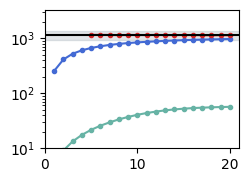

In [20]:
fig, ax = plt.subplots(figsize=(2.5, 1.8))
ax.set_yscale('log')
#plt.xlabel("lag time (ps)")
#plt.ylabel("ITS (ps)")

time_len = 20
ax.plot(range(1,time_len+1), F1d['ITS_tICA'][0][:time_len], '.-', c=colorG(), label='tICA')
ax.plot(range(1,time_len+1), F1d['ITS_AT'][0][:time_len], '.-', c=colorB(), label='AMUSEt-tICA')
ax.plot(range(5,time_len+1), F1d['ITS_IGME'][0][:time_len-4], '.-', c=RED, label='AMUSEt-tICA-IGME') 
y_max, y_min = 916, 1358
plt.axhspan(y_min, y_max, color=Slater, alpha=0.2, label='Gold Standard')
plt.axhline(.5*(y_min+y_max), color='k')

plt.xticks([0, 10, 20], fontsize=10)
plt.yticks([10, 100, 1000], fontsize=10)
plt.ylim([10, 3300])
#plt.legend()
plt.savefig('Panel_1d_ITS.svg', bbox_inches="tight", dpi=1000)
plt.show()

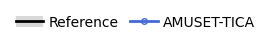

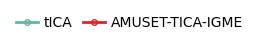

In [15]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

fig, ax_leg = plt.subplots(figsize=(2.5, 0.3))
ax_leg.axis("off")

band = Patch(facecolor="gray", alpha=0.3, edgecolor="none")
line = Line2D([0], [0], color="black", lw=2)
a_t = Line2D([0], [0], color=colorB(), marker='.', lw=2, markersize=8,
           markerfacecolor='none', label='AMUSEt-tICA')

legend_handles = [(band, line), a_t]
legend_labels = ['Reference', 'AMUSET-TICA']

ax_leg.legend(
    legend_handles,
    legend_labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc='center',
    ncol=2,
    frameon=False,
    fontsize=10,
    handleheight=0.8,
    columnspacing=0.8,
    handletextpad=0.4
)

fig.savefig("Panel_1d_ITS-legend1.svg", bbox_inches='tight', transparent=True)
plt.show()

fig_leg = plt.figure(figsize=(2.5, 0.3))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
legend_elements = [
    Line2D([0], [0], color=colorG(), marker='.', lw=2, markersize=8,
           markerfacecolor='none', label='tICA'),
    Line2D([0], [0], color=RED, marker='.', lw=2, markersize=8,
           markerfacecolor='none', label='AMUSET-TICA-IGME'),
]

leg = ax_leg.legend(
    handles=legend_elements,
    loc='center',
    ncol=5,
    frameon=False,
    fontsize=10,
    handlelength=1.6,
    columnspacing=0.8,
    handletextpad=0.4
)

fig_leg.savefig("Panel_1d_ITS-legend2.svg", bbox_inches='tight', transparent=True)
plt.show()

# Figure 1e: RMSD plots

In [5]:
vmin = [0, -.001, -.02]
vmean = [.003, 0, 0]
vmax = [.006, .001, .02]

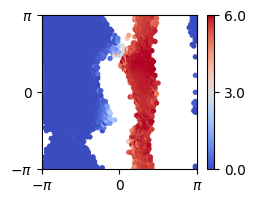

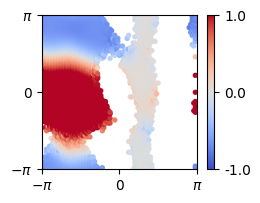

In [6]:
for i in range(2):
    read_in = []
    with open(f'Ala2_pred60lag-mode{i+1}_data.txt', "r") as f:
        for line in f:
            read_in.append(list(line.split()))
        read_in = np.array(read_in, dtype=np.float32)

    norm = colors.TwoSlopeNorm(vmin=vmin[i], vcenter=vmean[i], vmax=vmax[i])
    x, y, z = read_in[:, 0].flatten(), read_in[:, 1].flatten(), read_in[:, 2].flatten()
    mask = z == -10
    fig = plt.figure(figsize=(2.5, 2))
    ax = fig.add_subplot(111)
    sc = plt.scatter(x[~mask], y[~mask], c=z[~mask], s=8, cmap="coolwarm", norm=norm)
    #plt.xlabel(f"$\phi$")
    #plt.ylabel(f"$\psi$")
    #plt.title(f"CV[{i}]")
    plt.xlim([-180, 180])
    plt.ylim([-180, 180])
    ax.set_xticks([-180, 0, 180], [f"$-\pi$", "0", r"$\pi$"], fontsize=10)
    ax.set_yticks([-180, 0, 180], [f"$-\pi$", "0", r"$\pi$"], fontsize=10)
    cbar = plt.colorbar(sc)
    cbar.set_ticks([vmin[i], vmean[i], vmax[i]])
    cbar.set_ticklabels([f"{vmin[i]*1000:.1f}", f"{vmean[i]*1000:.1f}", f"{vmax[i]*1000:.1f}"], fontsize=10)
    plt.savefig(f'Ala2_pred_rama_{i+1}.svg', bbox_inches="tight", dpi=1000)
    plt.show()

# Figure 2a: RMSE

In [5]:
F2a = [np.load('Panel_2a1_RMSE.npz'), np.load('Panel_2a2_RMSE.npz')]
F2a

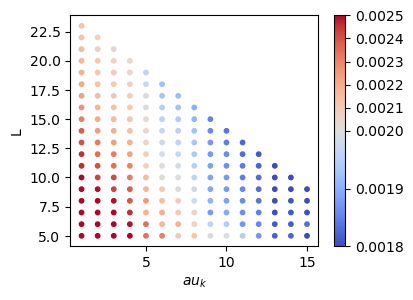

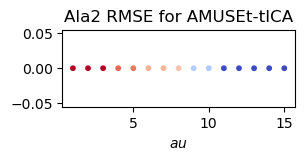

In [6]:
data = F2a[0]['data']
plt.figure(figsize=(4,3))
norm = colors.TwoSlopeNorm(vmin=.0018, vcenter=.0020, vmax=.0025)
plt.scatter(data[0], data[1], s=10, c=data[2], cmap="coolwarm", norm=norm)
plt.colorbar()#label='RMSE'
plt.xlabel(f'$\tau_k$')
plt.ylabel('L')
#plt.title('Ala2 RMSE for IGME')
plt.show() 

data = F2a[1]['data']
plt.figure(figsize=(3,1))
norm = colors.TwoSlopeNorm(vmin=.0018, vcenter=.0020, vmax=.0025)
plt.scatter(range(1, 16), [0]*15, s=10, c=data, cmap="coolwarm", norm=norm)
plt.xlabel(f'$\tau$')
plt.title('Ala2 RMSE for AMUSEt-tICA')
plt.show()

In [7]:
np.max(F2a[1]['data']), np.min(F2a[1]['data']), np.max(F2a[0]['data'][2]), np.min(F2a[0]['data'][2])

(0.005726942851251853,
 0.0014907374434430733,
 0.0025966466411447525,
 0.0017829500065351073)

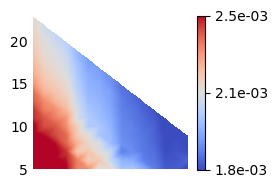

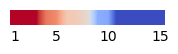

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# example scatter data
x = F2a[0]['data'][0]
y = F2a[0]['data'][1]
z = F2a[0]['data'][2]
norm = colors.TwoSlopeNorm(vmin=.0018, vcenter=.0021, vmax=.0025)

# create grid
xi = np.linspace(x.min(), x.max(), 300)
yi = np.linspace(y.min(), y.max(), 300)
XI, YI = np.meshgrid(xi, yi)

# interpolate
ZI = griddata((x, y), z, (XI, YI), method='linear')

# plot
plt.figure(figsize=(2.5, 2))
plt.box(False)
plt.imshow(
    ZI,
    extent=(x.min(), x.max(), y.min(), y.max()),
    origin='lower',
    aspect='auto',
    cmap='coolwarm',
    norm = norm
)
#plt.xticks([1, 5, 10, 15], fontsize=10)
plt.xticks([])
plt.yticks([5, 10, 15, 20], fontsize=10)
ax = plt.gca()
ax.tick_params(axis='both', which='both', length=0)
cbar = plt.colorbar()
cbar.set_ticks([.0018, .0021, .0025])
cbar.set_ticklabels([f"{.0018:.1e}", f"{ .0021:.1e}", f"{.0025:.1e}"], fontsize=10)
plt.savefig(f'Panel_2a1_RMSE.svg', bbox_inches="tight", dpi=1000)
plt.show()

fig, ax = plt.subplots(figsize=(2, .2))
plt.box(False)
ax.imshow(F2a[1]['data'][np.newaxis, :], 
          aspect='auto', cmap='coolwarm', norm=norm, interpolation="bilinear")
ax.set_xticks([0, 4, 9, 14])
ax.set_xticklabels([1, 5, 10, 15], fontsize=10)
ax.set_yticks([])                 # remove vertical axis
ax.tick_params(axis='x', length=0)

#plt.xlabel(f'$\tau$')
#plt.title('Ala2 RMSE for AMUSEt-tICA')
plt.savefig(f'Panel_2a2_RMSE.svg', bbox_inches="tight", dpi=1000)
plt.show()

# Figure 2b: savings

In [5]:
F2b = [np.load('Panel_2b1_savingRank.npz'), np.load('Panel_2b2_savingLagT.npz')]
F2b

[NpzFile 'Panel_2b1_savingRank.npz' with keys: title, usage,
 NpzFile 'Panel_2b2_savingLagT.npz' with keys: title, data, usage]

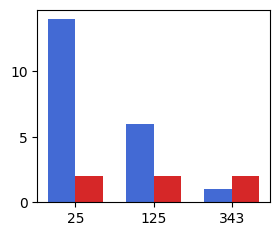

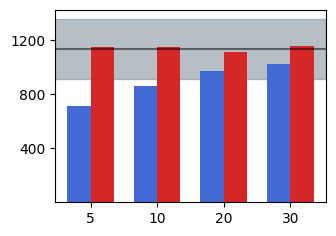

In [10]:
AT_tau_cs = [14, 6, 1]
IGME_tau_cs = [2, 2, 2]
categories = [25, 125, 343]
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(3, 2.5))
ax.bar(x - width/2, AT_tau_cs, width, color=colorB(), label='AMUSEt-tICA')
ax.bar(x + width/2, IGME_tau_cs, width, color=RED, label='AMUSEt-tICA-IGME')

plt.xticks(x, categories, fontsize=10)
plt.yticks([0, 5, 10], fontsize=10)
#ax.set_xlabel("Number of Basis")
#ax.set_ylabel("min traj len / ps")

#plt.legend()
plt.savefig('Panel_2b1_savingRank.svg', bbox_inches="tight", dpi=1000)
plt.show()

data = F2b[1]['data'][:, :-1]
x = np.arange(len(data[0]))
width = 0.35

fig, ax = plt.subplots(figsize = (3.5, 2.5))
y_max, y_min = 916, 1358
plt.axhline(.5*(y_min+y_max), color='k', alpha=0.5, label='Gold Standard')
plt.axhspan(y_min, y_max, color=Slater, alpha=0.5, label='Gold Standard err')
#ax.set_yscale('log')
ax.bar((x - width/2)[1:], data[1][1:], width, color=colorB(), label='AMUSEt-tICA w/ rank 25')
ax.bar((x + width/2)[1:], data[2][1:], width, color=RED, label='AMUSEt-tICA-IGME w/ rank 25')

plt.xticks(x[1:], [int(_) for _ in data[0][1:]], fontsize=10)
#ax.set_xlabel(r"lag time / ps ($\tau$ or $\tau_k$+L)")
#ax.set_ylabel("ITS / ps")
#plt.ylim([0, 1300])
plt.yticks([400, 800, 1200], fontsize=10)

#plt.legend()
plt.savefig('Panel_2b2_savingLagT.svg', bbox_inches="tight", dpi=1000)
plt.show()

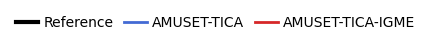

In [17]:
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='black', lw=3, label='Reference'),
    Line2D([0], [0], color=colorB(), lw=2, markersize=8,
           markerfacecolor='none', label='AMUSET-TICA'),
    Line2D([0], [0], color=RED, lw=2, markersize=8,
           markerfacecolor='none', label='AMUSET-TICA-IGME'),
]

fig_leg = plt.figure(figsize=(2.5, 0.3))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')

leg = ax_leg.legend(
    handles=legend_elements,
    loc='center',
    ncol=5,
    frameon=False,
    fontsize=10,
    handlelength=1.6,
    columnspacing=0.8,
    handletextpad=0.4
)

fig_leg.savefig("Panel_2b_saving-legend.svg", bbox_inches='tight', transparent=True)
plt.show()